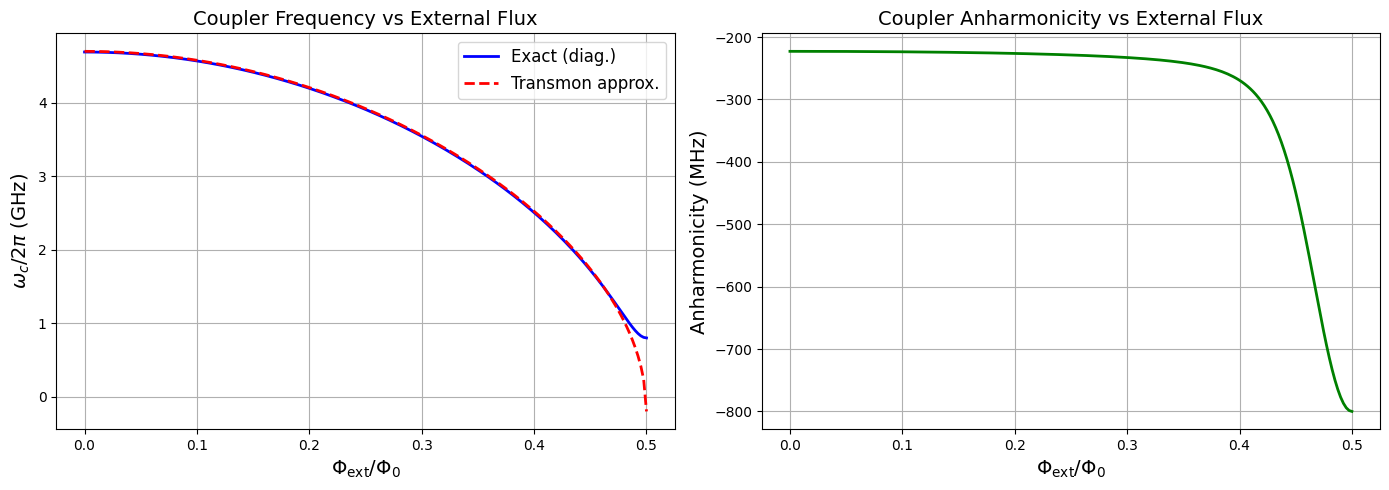

Sweet spot (Φ=0): ω_c = 4.690 GHz, α = -222.8 MHz
Φ = 0.25 Φ_0:     ω_c = 3.900 GHz, α = -228.7 MHz


In [1]:
import numpy as np
import qutip
import matplotlib.pyplot as plt

# ============================================================
# 2.1 磁通调制 coupler 频率：基础物理演示
# ============================================================

# --- 物理参数 ---
E_C = 0.2       # GHz, 充电能
E_J_sum = 15.0  # GHz, SQUID 总约瑟夫森能 (两个结之和)
N_charge = 30   # charge basis 截断: n = -N_charge ... +N_charge
dim = 2 * N_charge + 1

# --- 构建 charge basis 中的算符 ---
n_op = qutip.Qobj(np.diag(np.arange(-N_charge, N_charge + 1)))  # hat{n}

# cos(hat{phi}) 在 charge basis 中是: |n><n+1| + |n+1><n| 的求和 / 2
cos_phi = qutip.Qobj(0.5 * (np.diag(np.ones(dim - 1), 1) + 
                              np.diag(np.ones(dim - 1), -1)))
sin_phi = qutip.Qobj(0.5j * (np.diag(np.ones(dim - 1), -1) - 
                               np.diag(np.ones(dim - 1), 1)))

def coupler_hamiltonian(phi_ext, E_C, E_J_sum, n_op, cos_phi, sin_phi):
    """
    构建 SQUID coupler 的 Hamiltonian (对称 SQUID)
    
    H = 4 * E_C * n^2 - E_J_eff(Phi_ext) * cos(hat{phi})
    
    E_J_eff = E_J_sum * |cos(phi_ext)|
    
    Parameters
    ----------
    phi_ext : float
        外磁通相位 = pi * Phi_ext / Phi_0
    """
    E_J_eff = E_J_sum * np.abs(np.cos(phi_ext))
    H = 4 * E_C * n_op ** 2 - E_J_eff * cos_phi
    return H

def get_coupler_frequency(phi_ext, E_C, E_J_sum, n_op, cos_phi, sin_phi, 
                           n_levels=3):
    """计算 coupler 的前几个能级和频率"""
    H = coupler_hamiltonian(phi_ext, E_C, E_J_sum, n_op, cos_phi, sin_phi)
    energies = H.eigenenergies()[:n_levels]
    # qubit 频率 = E_1 - E_0
    omega_01 = energies[1] - energies[0]
    # 非谐性 = (E_2 - E_1) - (E_1 - E_0)
    anharmonicity = (energies[2] - energies[1]) - (energies[1] - energies[0])
    return omega_01, anharmonicity, energies


# --- 扫描外磁通，画出 coupler 频率 ---
phi_ext_list = np.linspace(0, 0.5 * np.pi, 200)  # 0 到 Phi_0/4
flux_list = phi_ext_list / np.pi  # 单位: Phi_0

omega_list = []
anhar_list = []

for phi_ext in phi_ext_list:
    omega, anhar, _ = get_coupler_frequency(
        phi_ext, E_C, E_J_sum, n_op, cos_phi, sin_phi
    )
    omega_list.append(omega)
    anhar_list.append(anhar)

omega_array = np.array(omega_list)
anhar_array = np.array(anhar_list)

# 与 transmon 近似公式对比
E_J_eff_approx = E_J_sum * np.abs(np.cos(phi_ext_list))
omega_approx = np.sqrt(8 * E_C * E_J_eff_approx) - E_C

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(flux_list, omega_array, 'b-', linewidth=2, label='Exact (diag.)')
axes[0].plot(flux_list, omega_approx, 'r--', linewidth=2, label='Transmon approx.')
axes[0].set_xlabel(r'$\Phi_{\mathrm{ext}} / \Phi_0$', fontsize=14)
axes[0].set_ylabel(r'$\omega_c / 2\pi$ (GHz)', fontsize=14)
axes[0].set_title('Coupler Frequency vs External Flux', fontsize=14)
axes[0].legend(fontsize=12)
axes[0].grid(True)

axes[1].plot(flux_list, anhar_array * 1000, 'g-', linewidth=2)
axes[1].set_xlabel(r'$\Phi_{\mathrm{ext}} / \Phi_0$', fontsize=14)
axes[1].set_ylabel('Anharmonicity (MHz)', fontsize=14)
axes[1].set_title('Coupler Anharmonicity vs External Flux', fontsize=14)
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Sweet spot (Φ=0): ω_c = {omega_array[0]:.3f} GHz, "
      f"α = {anhar_array[0]*1000:.1f} MHz")
print(f"Φ = 0.25 Φ_0:     ω_c = {omega_array[100]:.3f} GHz, "
      f"α = {anhar_array[100]*1000:.1f} MHz")

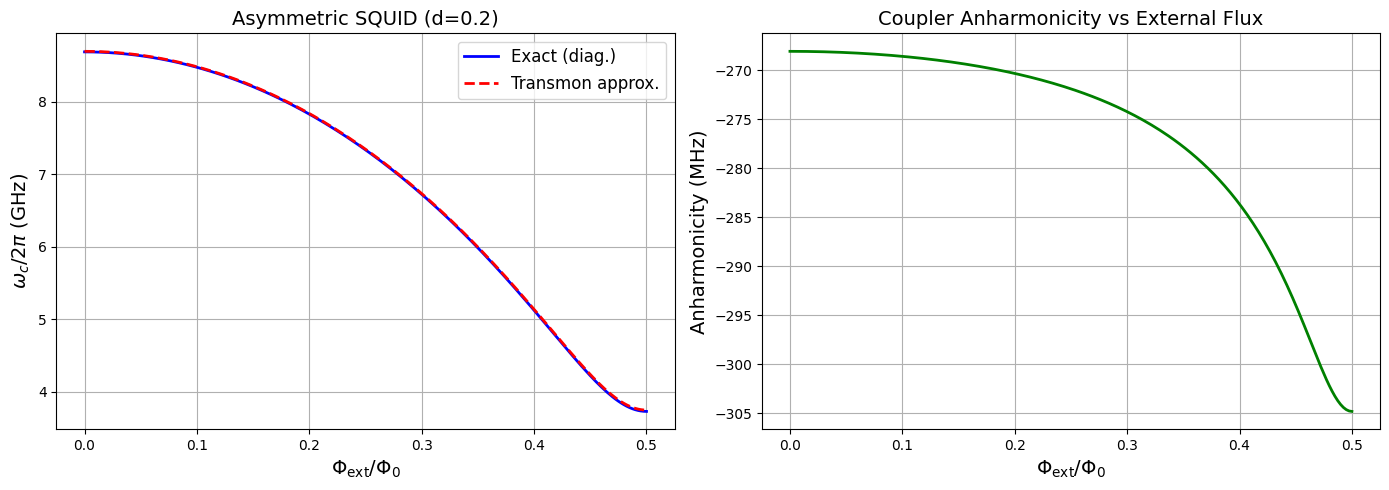

Sweet spot (Φ=0): ω_c = 8.687 GHz, α = -268.1 MHz
Φ = 0.25 Φ_0:     ω_c = 7.322 GHz, α = -272.0 MHz


In [2]:
# ============================================================
# 2.2 非对称 SQUID coupler 频率：基础物理演示
# ============================================================

E_C = 0.25       # ↑一点，提高最低频率
E_J_sum = 40.0   # ↑很多，拉高最高频率
d = 0.2          # 适中非对称（避免频率塌到太低）

N_charge = 30
dim = 2 * N_charge + 1

# --- 构建 charge basis 算符 ---
n_op = qutip.Qobj(np.diag(np.arange(-N_charge, N_charge + 1)))

cos_phi = qutip.Qobj(0.5 * (np.diag(np.ones(dim - 1), 1) + 
                            np.diag(np.ones(dim - 1), -1)))

sin_phi = qutip.Qobj(0.5j * (np.diag(np.ones(dim - 1), -1) - 
                             np.diag(np.ones(dim - 1), 1)))


def coupler_hamiltonian(phi_ext, E_C, E_J_sum, d, n_op, cos_phi, sin_phi):
    """
    非对称 SQUID Hamiltonian
    
    H = 4E_C n^2 - E_J_eff * cos(phi - phi0)
    
    E_J_eff = E_J_sum * sqrt(cos^2(phi_ext) + d^2 sin^2(phi_ext))
    tan(phi0) = d * tan(phi_ext)
    """

    cos_ext = np.cos(phi_ext)
    sin_ext = np.sin(phi_ext)

    # --- E_J_eff ---
    E_J_eff = E_J_sum * np.sqrt(cos_ext**2 + (d**2) * sin_ext**2)

    # --- 相位偏移 phi0 ---
    phi0 = np.arctan2(d * sin_ext, cos_ext)

    # --- cos(phi - phi0) 展开 ---
    cos_term = np.cos(phi0) * cos_phi + np.sin(phi0) * sin_phi

    H = 4 * E_C * n_op**2 - E_J_eff * cos_term
    return H


def get_coupler_frequency(phi_ext, E_C, E_J_sum, d,
                          n_op, cos_phi, sin_phi, n_levels=3):
    """计算 coupler 频率和非谐性"""
    H = coupler_hamiltonian(phi_ext, E_C, E_J_sum, d,
                            n_op, cos_phi, sin_phi)
    energies = H.eigenenergies()[:n_levels]

    omega_01 = energies[1] - energies[0]
    anharmonicity = (energies[2] - energies[1]) - (energies[1] - energies[0])

    return omega_01, anharmonicity, energies


# --- 扫描磁通 ---
phi_ext_list = np.linspace(0, 0.5 * np.pi, 200)
flux_list = phi_ext_list / np.pi

omega_list = []
anhar_list = []

for phi_ext in phi_ext_list:
    omega, anhar, _ = get_coupler_frequency(
        phi_ext, E_C, E_J_sum, d, n_op, cos_phi, sin_phi
    )
    omega_list.append(omega)
    anhar_list.append(anhar)

omega_array = np.array(omega_list)
anhar_array = np.array(anhar_list)

# --- transmon 近似 ---
cos_ext = np.cos(phi_ext_list)
sin_ext = np.sin(phi_ext_list)

E_J_eff_approx = E_J_sum * np.sqrt(cos_ext**2 + d**2 * sin_ext**2)
omega_approx = np.sqrt(8 * E_C * E_J_eff_approx) - E_C

# --- 画图 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(flux_list, omega_array, 'b-', linewidth=2, label='Exact (diag.)')
axes[0].plot(flux_list, omega_approx, 'r--', linewidth=2, label='Transmon approx.')
axes[0].set_xlabel(r'$\Phi_{\mathrm{ext}} / \Phi_0$', fontsize=14)
axes[0].set_ylabel(r'$\omega_c / 2\pi$ (GHz)', fontsize=14)
axes[0].set_title(f'Asymmetric SQUID (d={d})', fontsize=14)
axes[0].legend(fontsize=12)
axes[0].grid(True)

axes[1].plot(flux_list, anhar_array * 1000, 'g-', linewidth=2)
axes[1].set_xlabel(r'$\Phi_{\mathrm{ext}} / \Phi_0$', fontsize=14)
axes[1].set_ylabel('Anharmonicity (MHz)', fontsize=14)
axes[1].set_title('Coupler Anharmonicity vs External Flux', fontsize=14)
axes[1].grid(True)

plt.tight_layout()
plt.show('asym-coupler_frequency.png')

print(f"Sweet spot (Φ=0): ω_c = {omega_array[0]:.3f} GHz, "
      f"α = {anhar_array[0]*1000:.1f} MHz")
print(f"Φ = 0.25 Φ_0:     ω_c = {omega_array[100]:.3f} GHz, "
      f"α = {anhar_array[100]*1000:.1f} MHz")

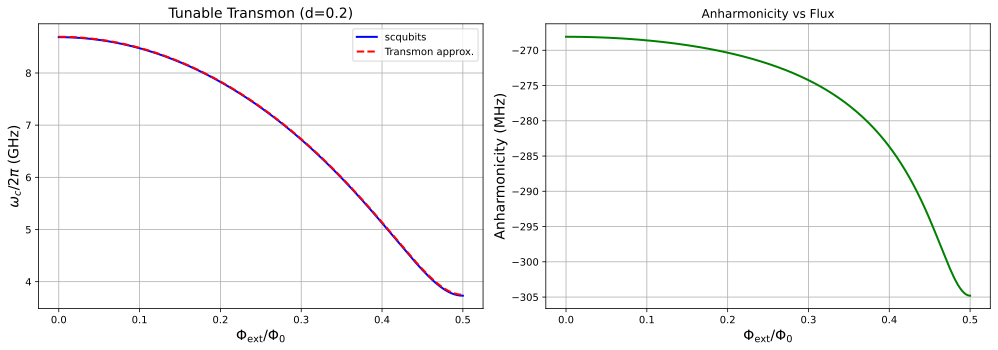

Φ=0:      ω = 8.687 GHz, α = -268.1 MHz
Φ=0.25:   ω = 7.322 GHz, α = -272.0 MHz


In [3]:

import numpy as np
import matplotlib.pyplot as plt
import scqubits as scq

# ============================================================
# Tunable transmon (asymmetric SQUID) coupler with scqubits
# ============================================================

# --- 参数（和你刚刚调好的范围一致）---
EC = 0.25        # GHz
EJmax = 40.0     # GHz
d = 0.2          # 非对称参数

cutoff = 30      # charge basis 截断（类似你的 N_charge）

# --- 构建 tunable transmon ---
tmon = scq.TunableTransmon(
    EJmax=EJmax,
    EC=EC,
    d=d,
    ng=0.0,
    flux=0.1,
    ncut=cutoff
)

# --- 扫 flux ---
flux_list = np.linspace(0, 0.5, 200)   # 单位: Phi_ext / Phi_0

omega_list = []
anhar_list = []

for flux in flux_list:
    tmon.flux = flux

    evals = tmon.eigenvals(evals_count=3)

    omega_01 = evals[1] - evals[0]
    anharm = (evals[2] - evals[1]) - (evals[1] - evals[0])

    omega_list.append(omega_01)
    anhar_list.append(anharm)

omega_array = np.array(omega_list)
anhar_array = np.array(anhar_list)

# --- transmon 近似（非对称版）---
phi_ext_list = np.pi * flux_list
cos_ext = np.cos(phi_ext_list)
sin_ext = np.sin(phi_ext_list)

EJ_eff = EJmax * np.sqrt(cos_ext**2 + d**2 * sin_ext**2)
omega_approx = np.sqrt(8 * EC * EJ_eff) - EC

# --- 画图 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(flux_list, omega_array, 'b-', linewidth=2, label='scqubits')
axes[0].plot(flux_list, omega_approx, 'r--', linewidth=2, label='Transmon approx.')
axes[0].set_xlabel(r'$\Phi_{\mathrm{ext}} / \Phi_0$', fontsize=14)
axes[0].set_ylabel(r'$\omega_c / 2\pi$ (GHz)', fontsize=14)
axes[0].set_title(f'Tunable Transmon (d={d})', fontsize=14)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(flux_list, anhar_array * 1000, 'g-', linewidth=2)
axes[1].set_xlabel(r'$\Phi_{\mathrm{ext}} / \Phi_0$', fontsize=14)
axes[1].set_ylabel('Anharmonicity (MHz)', fontsize=14)
axes[1].set_title('Anharmonicity vs Flux')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Φ=0:      ω = {omega_array[0]:.3f} GHz, α = {anhar_array[0]*1000:.1f} MHz")
print(f"Φ=0.25:   ω = {omega_array[100]:.3f} GHz, α = {anhar_array[100]*1000:.1f} MHz")